# 3D Molecular Dynamics with a learned interatomic potential (MLIP)

### Markus J. Buehler, MIT

A self-contained pedagogical notebook in which we train a small **tanh neural pair-potential MLIP** to mimic any pair potential the user picks.

The user can pick the **training data** in an interactive widget:

* **Default**: the Morse pair potential with user-chosen $D_e$, $a$, and $r_e$.
* **Draw your own**: move vertical control points to sketch $V(r)$; the spline through those points becomes a smooth target.
* **Upload**: a CSV with two columns ($r$, $V$) defines a custom potential.

Whatever $V(r)$ you choose becomes the ground-truth pair interaction. The MLIP is a single-hidden-layer neural network $V_\theta(r)$ with tanh activations and a smooth cutoff, trained directly on both $V(r)$ and $dV/dr$.

Everything runs in NumPy + SciPy + matplotlib + ipywidgets.


In [1]:
import io
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

from scipy.interpolate import CubicSpline

import ipywidgets as widgets
from ipywidgets import (IntSlider, FloatSlider, Dropdown, Button, FileUpload,
                        Output, VBox, HBox, Layout, HTML)
from IPython.display import display, clear_output, HTML as IPyHTML

# No ipycanvas dependency is needed.  The draw editor below uses only
# standard ipywidgets controls; the MLIP itself is a tanh neural network.

np.random.seed(0)
print('numpy', np.__version__, ' | matplotlib', mpl.__version__)


numpy 2.2.6  | matplotlib 3.10.1


## 1. Setting up a 3D system

We use a small **face-centered-cubic (FCC) lattice** in 3D — the stable close-packed ground state for simple pair potentials like Morse. (A simple-cubic lattice has zero shear stiffness and spontaneously rearranges even at very low temperature, which looks like melting; FCC vibrates stably around its equilibrium.) Each conventional cubic cell holds 4 atoms, so $n_x = n_y = n_z = 3$ cells gives $N = 4 \cdot 3^3 = 108$ atoms, small enough that the live MD panel renders at interactive frame rates. The conventional cell edge is $a_\text{lat}$ and the nearest-neighbour distance is $a_\text{lat}/\sqrt{2}$. Velocities are sampled from a Maxwell–Boltzmann distribution at $T_\text{init}$, with zero centre-of-mass momentum and exactly rescaled to match $T_\text{init}$ ($\langle KE \rangle = \tfrac{3}{2}N k_B T$ in 3D).


In [2]:
FCC_BASIS = np.array([[0.0, 0.0, 0.0], [0.0, 0.5, 0.5],
                      [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]])

def make_lattice_3d(nx, ny, nz, a_lat=1.37):
    """Face-centered-cubic (FCC) lattice in 3D — the stable close-packed ground state
    for simple pair potentials. (A simple-cubic lattice has zero shear stiffness and
    rearranges even at T->0, which looks like melting.) `a_lat` is the conventional
    cubic cell edge; nearest-neighbour distance is a_lat/sqrt(2). Returns positions
    (N, 3) with N = 4*nx*ny*nz, and box dims (3,)."""
    cells = np.array([[i, j, k] for i in range(nx) for j in range(ny) for k in range(nz)],
                     dtype=np.float64)
    pos = (cells[:, None, :] + FCC_BASIS[None, :, :]).reshape(-1, 3) * a_lat
    Lbox = np.array([nx * a_lat, ny * a_lat, nz * a_lat])
    return pos, Lbox

def init_velocities_3d(N, T, mass=1.0, rng=None):
    """3D Maxwell–Boltzmann velocities, zero COM, exactly at temperature T (k_B = 1)."""
    rng = np.random.default_rng() if rng is None else rng
    v = rng.normal(size=(N, 3)) * np.sqrt(T / mass)
    v -= v.mean(axis=0)
    KE = 0.5 * mass * (v ** 2).sum()
    # 3D, k_B = 1:  <KE> = (3/2) N k_B T  =>  T = (2/3) KE / N
    T_actual = (2.0 / 3.0) * KE / N
    if T_actual > 0:
        v *= np.sqrt(T / T_actual)
    return v


## 2. The Morse pair potential (our default "ground truth")

Using the **cohesive form**, $V(r) = D_e\bigl[1 - e^{-a(r - r_e)}\bigr]^2 - D_e$, so $V(r_e) = -D_e$ (bound state) and $V(\infty) = 0$ (isolated atoms). This is the convention real MLIP-training datasets use, and what the spline / upload paths below also produce.

The MLIP we'll train below has a finite cutoff $r_\text{c}$; we apply the same cutoff to Morse (a smooth cosine window) so the *target* values smoothly go to zero at $r_\text{c}$. This way the MLIP's natural "forget about pairs past $r_\text{c}$" doesn't bake in a systematic energy offset relative to the analytic Morse curve.

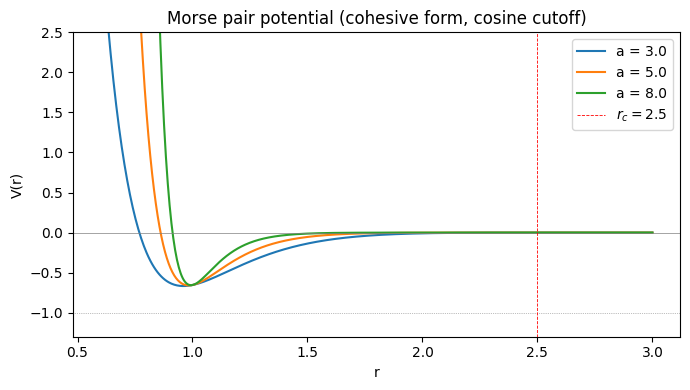

In [3]:
RCUT = 2.5   # global cutoff radius used by Morse, custom V, and the neural-pair MLIP

def smooth_cutoff(r, rc=RCUT):
    """Cosine smooth-cutoff f_c(r): 1 at r=0, smoothly 0 at r=rc."""
    inside = r < rc
    return np.where(inside, 0.5 * (np.cos(np.pi * r / rc) + 1.0), 0.0)

def smooth_cutoff_deriv(r, rc=RCUT):
    inside = r < rc
    return np.where(inside, -0.5 * (np.pi / rc) * np.sin(np.pi * r / rc), 0.0)

def morse_pair(r, De=1.0, a=5.0, re=1.0, rc=RCUT):
    """Morse pair potential V(r) in cohesive form, multiplied by the cutoff f_c(r).
    Returns (V, dV/dr)."""
    e = np.exp(-a * (r - re))
    V_raw  = De * (1.0 - e) ** 2 - De
    dV_raw = 2.0 * a * De * (1.0 - e) * e
    fc  = smooth_cutoff(r, rc)
    dfc = smooth_cutoff_deriv(r, rc)
    V  = V_raw * fc
    dV = dV_raw * fc + V_raw * dfc
    return V, dV

# Quick sanity plot: V_Morse(r) for a few stiffness values a, all with the smooth cutoff
r_grid = np.linspace(0.6, 3.0, 600)
fig, ax = plt.subplots(figsize=(7, 4))
for a_val in [3.0, 5.0, 8.0]:
    V, _ = morse_pair(r_grid, De=1.0, a=a_val, re=1.0)
    ax.plot(r_grid, V, label=f'a = {a_val}')
ax.axhline(0, color='gray', lw=0.5)
ax.axhline(-1.0, color='gray', lw=0.5, ls=':')
ax.axvline(RCUT, color='red', ls='--', lw=0.6, label=f'$r_c = {RCUT}$')
ax.set_xlabel('r'); ax.set_ylabel('V(r)')
ax.set_title('Morse pair potential (cohesive form, cosine cutoff)')
ax.set_ylim(-1.3, 2.5)
ax.legend(); plt.tight_layout(); plt.show()


## 3. Pairwise forces in 3D from any V(r)

A single routine takes any callable that returns $(V, dV/dr)$ and computes per-atom force, energy and virial. The Morse-specific and MLIP-specific code below uses it (Morse) or a parallel chain-rule version (MLIP). Boundary conditions: minimum-image periodic.

In [4]:
def _pairwise_3d(pos, Lbox, bc='periodic'):
    """Returns dx (N, N, 3) and r (N, N) with diagonal r set to 1 to avoid div/0."""
    dx = pos[:, None, :] - pos[None, :, :]
    if bc == 'periodic':
        dx -= Lbox * np.round(dx / Lbox)
    r2 = (dx ** 2).sum(-1)
    np.fill_diagonal(r2, 1.0)
    return dx, np.sqrt(r2)

def compute_forces_pair(pos, Lbox, V_dV_func, bc='periodic'):
    """3D forces for any pair potential defined by V_dV_func(r) -> (V, dV/dr).
    Returns (F, pe_per, vir_per) matching the analogous 2D routines."""
    dx, r = _pairwise_3d(pos, Lbox, bc)
    V, dV_dr = V_dV_func(r)
    np.fill_diagonal(V, 0.0); np.fill_diagonal(dV_dr, 0.0)
    factor = -dV_dr / r
    np.fill_diagonal(factor, 0.0)
    F_ij = factor[:, :, None] * dx               # (N, N, 3)
    F = F_ij.sum(axis=1)                          # (N, 3)
    pe_per  = 0.5 * V.sum(axis=1)                 # (N,)
    vir_per = 0.5 * (dx * F_ij).sum(axis=(1, 2))  # (N,)
    return F, pe_per, vir_per

# Convenience wrapper for the Morse target
def compute_forces_morse_3d(pos, Lbox, De=1.0, a=5.0, re=1.0, bc='periodic'):
    return compute_forces_pair(pos, Lbox, lambda r: morse_pair(r, De, a, re), bc=bc)

## 4. 3D MD simulator

Velocity Verlet, dispatches on a `potential` attribute that picks the force routine. Three potential types are supported: `'Morse'`, `'Custom'` (spline-defined V), and `'MLIP'` (trained network). Each carries its own `potential_params` dict.

Two boundary conditions are available via `bc`: `'periodic'` (minimum-image, an infinite crystal) and `'reflecting'` (an open box whose walls specularly bounce atoms back — a finite container). Reflecting walls conserve energy but not momentum.


In [5]:
class MDSimulator3D:
    def __init__(self, nx=3, ny=3, nz=3, a_lat=1.37, bc='periodic',
                 T_init=0.03, mass=1.0, seed=0,
                 potential='Morse', potential_params=None,
                 thermostat='none', T_target=None, tau_T=1.0, dt=0.005):
        rng = np.random.default_rng(seed)
        self.pos, self.Lbox = make_lattice_3d(nx, ny, nz, a_lat)
        self.N   = self.pos.shape[0]
        self.vel = init_velocities_3d(self.N, T_init, mass, rng)
        self.mass = mass
        self.bc   = bc

        self.potential        = potential
        self.potential_params = dict(potential_params) if potential_params else {}
        self.thermostat       = thermostat
        self.T_target         = T_target
        self.tau_T            = tau_T
        self.dt               = dt

        self.step_count = 0
        self.time = 0.0
        self._rescale_counter = 0
        self.F, self.pe_per, self.vir_per = self._forces()

    def _forces(self):
        p = self.potential_params
        if self.potential == 'Morse':
            return compute_forces_morse_3d(self.pos, self.Lbox, bc=self.bc, **p)
        if self.potential == 'Custom':
            return compute_forces_pair(self.pos, self.Lbox, p['V_dV_func'], bc=self.bc)
        if self.potential == 'MLIP':
            return compute_forces_mlip(self.pos, self.Lbox, p['weights'], p['hp'], bc=self.bc)
        raise ValueError(f'unknown potential: {self.potential}')

    def _apply_bc(self):
        """Periodic wrap or specular reflection off the box walls [0, L]."""
        if self.bc == 'periodic':
            self.pos -= self.Lbox * np.floor(self.pos / self.Lbox)
        elif self.bc == 'reflecting':
            under = self.pos < 0.0
            self.pos = np.where(under, -self.pos, self.pos)
            self.vel = np.where(under, -self.vel, self.vel)
            over = self.pos > self.Lbox
            self.pos = np.where(over, 2.0 * self.Lbox - self.pos, self.pos)
            self.vel = np.where(over, -self.vel, self.vel)
            # clamp any residue from a double-bounce within one step
            self.pos = np.clip(self.pos, 0.0, self.Lbox)
        # bc == 'none' (open box): nothing to do

    def step(self):
        dt = self.dt
        self.vel += 0.5 * dt * self.F / self.mass
        self.pos += dt * self.vel
        self._apply_bc()
        self.F, self.pe_per, self.vir_per = self._forces()
        self.vel += 0.5 * dt * self.F / self.mass
        if self.T_target is not None and self.thermostat != 'none':
            KE = 0.5 * self.mass * (self.vel ** 2).sum()
            T_cur = max((2.0 / 3.0) * KE / self.N, 1e-12)
            self._rescale_counter += 1
            if self.thermostat == 'rescale' and self._rescale_counter % 50 == 0:
                self.vel *= np.sqrt(self.T_target / T_cur)
            elif self.thermostat == 'berendsen':
                lam = np.sqrt(max(0.0, 1.0 + (dt / self.tau_T) * (self.T_target / T_cur - 1.0)))
                self.vel *= lam
        self.step_count += 1
        self.time += dt

    def snapshot(self):
        KE = 0.5 * self.mass * (self.vel ** 2).sum()
        return dict(
            pos=self.pos.copy(), vel=self.vel.copy(),
            pe_per=self.pe_per.copy(),
            T=(2.0 / 3.0) * KE / self.N, KE=KE, PE=float(self.pe_per.sum()),
            time=self.time, step=self.step_count,
            Lbox=self.Lbox.copy(), potential=self.potential,
        )

# Smoke test on Morse
_sim = MDSimulator3D(nx=3, ny=3, nz=3, a_lat=1.37, T_init=0.02,
                     potential='Morse', potential_params=dict(De=1.0, a=5.0, re=1.0))
_E0 = _sim.pe_per.sum() + 0.5 * (_sim.vel ** 2).sum()
for _ in range(500):
    _sim.step()
_s = _sim.snapshot()
print(f'Morse 3D smoke test: 500 NVE steps, '
      f'E drift = {_s["KE"] + _s["PE"] - _E0:+.2e}, T_final = {_s["T"]:.4f}')

# Reflecting-wall smoke test (open box, atoms bounce off the faces)
_simR = MDSimulator3D(nx=3, ny=3, nz=3, a_lat=1.37, bc='reflecting', T_init=0.05,
                      potential='Morse', potential_params=dict(De=1.0, a=5.0, re=1.0))
_E0R = _simR.pe_per.sum() + 0.5 * (_simR.vel ** 2).sum()
for _ in range(500):
    _simR.step()
_sR = _simR.snapshot()
_inside = ((_simR.pos >= 0) & (_simR.pos <= _simR.Lbox)).all()
print(f'Reflecting-wall smoke test: 500 steps, E drift = {_sR["KE"] + _sR["PE"] - _E0R:+.2e}, '
      f'all atoms inside box = {bool(_inside)}')


Morse 3D smoke test: 500 NVE steps, E drift = +1.67e-03, T_final = 0.0091
Reflecting-wall smoke test: 500 steps, E drift = +2.24e-02, all atoms inside box = True


## 5. The neural-pair MLIP architecture (3D)

The target is a pair potential $V(r)$, so the MLIP is a **one-hidden-layer neural network** of the scalar input $r$:

$$V_\theta(r) = \Big[b + \sum_{j=1}^{H} c_j\,\tanh\!\big(w_j\,r + b_j\big)\Big]\, f_\text{c}(r).$$

Unlike a fixed-feature model, **every parameter is learned**: the hidden weights $w_j$ and biases $b_j$ (which set where and how steeply each tanh turns on) as well as the output weights $c_j$ and bias $b$. The total energy is $E_\theta = \sum_{i<j} V_\theta(r_{ij})$, and the forces are the analytic pair forces from $-dV_\theta/dr$, so they are exactly consistent with $V_\theta$.

Because the network is differentiable, we can train it by gradient descent with **Adam / AdamW** (Section 6), matching both $V(r)$ and its slope $dV/dr$. As a fast reference, you can also pick the **CG** option, which freezes the hidden layer on a grid and solves the (then linear) output layer exactly.


In [6]:
def make_mlip_hparams(H=80, alpha=20.0, rc=RCUT, mu_lo=0.55, mu_hi=None):
    """Hyperparameters for the neural pair-potential MLIP. `alpha` and `mu` are only
    used to seed/grid the hidden layer (fixed for the CG solver, initial guess for Adam)."""
    H = int(H)
    mu_hi = rc + 0.05 if mu_hi is None else mu_hi
    mu = np.linspace(mu_lo, mu_hi, H)
    return dict(model='neural_pair_mlp', H=H, alpha=float(alpha), rc=float(rc),
                mu=mu.tolist(), activation='tanh')


def mlip_pair_vdv(r, weights, hp):
    """Learned 1-hidden-layer MLP pair potential and its derivative:
       raw(r) = sum_j c_j * tanh(w_j * r + b_in_j) + b_out ;  V(r) = raw(r) * f_c(r)."""
    r_arr = np.asarray(r, dtype=np.float64)
    shape = r_arr.shape
    rf = r_arr.reshape(-1)
    w    = np.asarray(weights['w'],    dtype=np.float64).reshape(-1)
    b_in = np.asarray(weights['b_in'], dtype=np.float64).reshape(-1)
    c    = np.asarray(weights['c'],    dtype=np.float64).reshape(-1)
    b_out = float(weights['b_out'])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        z = rf[:, None] * w[None, :] + b_in[None, :]
        h = np.tanh(z)
        raw = h @ c + b_out
        d_raw = ((1.0 - h ** 2) * w[None, :]) @ c
    fc = smooth_cutoff(rf, hp['rc'])
    dfc = smooth_cutoff_deriv(rf, hp['rc'])
    V = raw * fc
    dV = d_raw * fc + raw * dfc
    return V.reshape(shape), dV.reshape(shape)


def compute_forces_mlip(pos, Lbox, weights, hp, bc='periodic'):
    """3D forces for the learned neural pair-potential MLIP."""
    return compute_forces_pair(pos, Lbox, lambda r: mlip_pair_vdv(r, weights, hp), bc=bc)


# ---- Consistency check: MLIP force path equals the generic pair loop ----
_rng = np.random.default_rng(42)
_pos = _rng.uniform(0.0, 5.0, (6, 3))
_Lbox = np.array([5.0, 5.0, 5.0])
_hp = make_mlip_hparams(H=12)
_w = {'mode': 'neural_pair_mlp',
      'w': _rng.standard_normal(_hp['H']),
      'b_in': _rng.standard_normal(_hp['H']),
      'c': 0.1 * _rng.standard_normal(_hp['H']),
      'b_out': 0.0}
_F_mlip, _pe_mlip, _ = compute_forces_mlip(_pos, _Lbox, _w, _hp)
_F_pair, _pe_pair, _ = compute_forces_pair(_pos, _Lbox, lambda r: mlip_pair_vdv(r, _w, _hp))
_err = float(max(np.abs(_F_mlip - _F_pair).max(), np.abs(_pe_mlip - _pe_pair).max()))
print(f'MLP neural-pair consistency check: max |Δ| = {_err:.2e}')
assert _err < 1e-12
print(f'Newton 3rd law:                   max |F.sum(0)| = {np.abs(_F_mlip.sum(0)).max():.2e}')


MLP neural-pair consistency check: max |Δ| = 0.00e+00
Newton 3rd law:                   max |F.sum(0)| = 6.94e-18


## 6. Training the neural potential

Training samples the chosen target on a dense set of pair distances (the **datapoints** control) and minimises a weighted loss over both the pair energy $V(r)$ and its slope $dV/dr$.

Pick the **optimizer**:

* **Adam / AdamW** — true neural-network training. *All* weights (hidden $w_j, b_j$ and output $c_j, b$) are learned by gradient descent with PyTorch autograd (the $dV/dr$ term uses double-backprop). The input is standardized and the learning rate follows a cosine decay. Watch the **loss fall over epochs**; raise **epochs** / **learn rate** for a tighter fit.
* **CG (fast)** — freezes the hidden layer on a grid so the output layer is linear, then solves it exactly by conjugate gradient. Fewer epochs needed and a very tight fit, but it is not "training the whole network".

The per-epoch loss is recorded and plotted, and the post-fit pair-energy overlay shows how closely the learned $V_\theta(r)$ matches the target.


In [15]:
import torch


def train_mlip(V_dV_func, *, H=80, alpha=20.0, n_pair=1040, ridge=1e-8,
               derivative_weight=0.05, n_epochs=2000, optimizer='Adam',
               learning_rate=0.05, progress_cb=None, seed=0):
    """Train the neural pair-potential MLIP to V(r) and dV/dr.

    optimizer='Adam'/'AdamW'  -> full network trained with PyTorch + autograd
                                 (hidden and output layers, cosine LR schedule).
    optimizer='CG'            -> hidden layer fixed on a grid, output layer solved
                                 exactly by conjugate gradient (fast reference).
    Each *epoch* is one full-batch optimisation step; the per-epoch loss is logged.
    `n_pair` sets how many pair-distance datapoints the curve is sampled on.
    """
    H = int(H)
    n_pair = int(max(n_pair, 8 * H))
    n_epochs = int(max(1, n_epochs))
    ridge = float(ridge)
    hp = make_mlip_hparams(H=H, alpha=alpha)

    n1 = max(260, n_pair // 4)
    n2 = max(360, n_pair // 3)
    n3 = max(460, n_pair - n1 - n2)
    r_fit = np.unique(np.concatenate([
        np.linspace(0.60, 0.90, n1),
        np.linspace(0.90, 1.35, n2),
        np.linspace(1.35, hp['rc'], n3),
    ])).astype(np.float64)

    V_fit, dV_fit = V_dV_func(r_fit)
    V_fit = np.asarray(V_fit, dtype=np.float64)
    dV_fit = np.asarray(dV_fit, dtype=np.float64)
    finite = np.isfinite(V_fit) & np.isfinite(dV_fit)
    if finite.sum() < 20:
        raise ValueError('not enough finite target samples to train the MLIP')
    r_fit, V_fit, dV_fit = r_fit[finite], V_fit[finite], dV_fit[finite]

    rc = hp['rc']
    fc = smooth_cutoff(r_fit, rc)
    dfc = smooth_cutoff_deriv(r_fit, rc)
    V_scale = float(max(1.0, np.percentile(np.abs(V_fit), 95)))
    F_scale = float(max(1.0, np.percentile(np.abs(dV_fit), 95)))
    wv = 1.0 / np.maximum(1.0, np.abs(V_fit) / 20.0)
    wf = 1.0 / np.maximum(1.0, np.abs(dV_fit) / 120.0)

    epochs, losses = [], []

    if str(optimizer).upper() == 'CG':
        # ---- fixed-feature linear model solved by conjugate gradient ----
        mu = np.asarray(hp['mu'], dtype=np.float64)
        al = float(hp['alpha'])
        phi = np.tanh(al * (r_fit[:, None] - mu[None, :]))
        dphi = al * (1.0 - phi ** 2)
        Phi = np.column_stack([phi, np.ones(len(r_fit))])
        dPhi = np.column_stack([dphi, np.zeros(len(r_fit))])
        A_V = fc[:, None] * Phi
        A_dV = dfc[:, None] * Phi + fc[:, None] * dPhi
        A = np.vstack([(wv[:, None] / V_scale) * A_V,
                       (derivative_weight * wf[:, None] / F_scale) * A_dV])
        y = np.concatenate([(wv / V_scale) * V_fit,
                            (derivative_weight * wf / F_scale) * dV_fit])
        if ridge > 0:
            A = np.vstack([A, np.sqrt(ridge) * np.eye(H + 1)])
            y = np.concatenate([y, np.zeros(H + 1)])
        col_norm = np.sqrt((A ** 2).sum(axis=0)); col_norm[col_norm == 0.0] = 1.0
        As = A / col_norm
        G = As.T @ As; g = As.T @ y; yty = float(y @ y); n_rows = float(len(y))
        cs = np.zeros(H + 1); rk = g - G @ cs; pk = rk.copy(); rs = float(rk @ rk)
        cb_every = max(1, n_epochs // 10)
        for ep in range(n_epochs):
            Gp = G @ pk; a = rs / (float(pk @ Gp) + 1e-30)
            cs += a * pk; rk -= a * Gp
            rs2 = float(rk @ rk); pk = rk + (rs2 / (rs + 1e-30)) * pk; rs = rs2
            loss = (float(cs @ (G @ cs)) - 2.0 * float(g @ cs) + yty) / n_rows
            epochs.append(ep + 1); losses.append(max(loss, 1e-30))
            if progress_cb is not None and (ep % cb_every == 0 or ep == n_epochs - 1):
                progress_cb(ep, n_epochs, loss)
        coeff = cs / col_norm
        weights = {'mode': 'neural_pair_mlp',
                   'w': (al * np.ones(H)).tolist(),
                   'b_in': (-al * mu).tolist(),
                   'c': coeff[:H].tolist(),
                   'b_out': float(coeff[-1])}
    else:
        # ---- full neural-network training with PyTorch (Adam / AdamW) ----
        torch.manual_seed(seed); np.random.seed(seed)
        rm, rsd = float(r_fit.mean()), float(r_fit.std() + 1e-12)
        mu = np.linspace(r_fit.min(), r_fit.max(), H)
        s0 = 2.0
        w  = torch.tensor(np.full(H, s0 / rsd), requires_grad=True)
        bi = torch.tensor(-s0 * (mu - rm) / rsd, requires_grad=True)
        c  = torch.tensor(0.05 * np.random.standard_normal(H), requires_grad=True)
        bo = torch.zeros(1, dtype=torch.float64, requires_grad=True)
        params = [w, bi, c, bo]
        rt  = torch.tensor(r_fit, dtype=torch.float64, requires_grad=True)
        Vt  = torch.tensor(V_fit);  dVt = torch.tensor(dV_fit)
        wvt = torch.tensor(wv);     wft = torch.tensor(wf)
        opt_cls = torch.optim.AdamW if str(optimizer).upper() == 'ADAMW' else torch.optim.Adam
        opt = opt_cls(params, lr=float(learning_rate), weight_decay=ridge)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_epochs)
        pi = float(np.pi)

        def fc_torch(x):
            return torch.where(x < rc, 0.5 * (torch.cos(pi * x / rc) + 1.0), torch.zeros_like(x))

        cb_every = max(1, n_epochs // 10)
        for ep in range(n_epochs):
            opt.zero_grad()
            rstd = (rt - rm) / rsd
            z = rstd.unsqueeze(1) * w.unsqueeze(0) + bi.unsqueeze(0)
            raw = torch.tanh(z) @ c + bo
            Vp = raw * fc_torch(rt)
            dVp = torch.autograd.grad(Vp.sum(), rt, create_graph=True)[0]
            loss = (wvt * ((Vp - Vt) / V_scale) ** 2).mean() \
                 + derivative_weight * (wft * ((dVp - dVt) / F_scale) ** 2).mean()
            loss.backward()
            opt.step(); sched.step()
            lval = float(loss.detach())
            epochs.append(ep + 1); losses.append(max(lval, 1e-30))
            if progress_cb is not None and (ep % cb_every == 0 or ep == n_epochs - 1):
                progress_cb(ep, n_epochs, lval)
        # fold input standardization back into plain-r weights
        w_np = w.detach().numpy(); bi_np = bi.detach().numpy()
        weights = {'mode': 'neural_pair_mlp',
                   'w': (w_np / rsd).tolist(),
                   'b_in': (bi_np - w_np * rm / rsd).tolist(),
                   'c': c.detach().numpy().tolist(),
                   'b_out': float(bo.detach().numpy()[0])}

    V_pred, dV_pred = mlip_pair_vdv(r_fit, weights, hp)
    V_rmse = float(np.sqrt(np.mean((V_pred - V_fit) ** 2)))
    dV_rmse = float(np.sqrt(np.mean((dV_pred - dV_fit) ** 2)))
    log = {'epoch': epochs, 'loss': losses, 'V_rmse': V_rmse, 'dV_rmse': dV_rmse,
           'n_pair': int(len(r_fit)), 'n_epochs': n_epochs,
           'optimizer': str(optimizer), 'lr': float(learning_rate), 'n_md': 0}
    return weights, hp, log


## 7. The fitting widget — pick your training data and train the MLIP

Use the dropdown to choose the **dataset source**:

* **Morse**: the analytic Morse pair potential with adjustable $D_e$, $a$, $r_e$ sliders. The default.
* **Draw your own**: **click and drag with your mouse on the canvas** to sketch any $V(r)$ freehand. Use **Trace Morse** to seed the current Morse shape, **Clear** to flatten it, and **Smooth** (with the σ slider) to clean up a shaky stroke. The drawn curve — interpolated and multiplied by the smooth cutoff — becomes the training target.
* **Upload CSV**: load a custom $V(r)$ from a two-column file (`r, V` with a header row); it is loaded onto the drawing canvas where you can further tweak or smooth it.

The **Training settings** pick the **optimizer** (**Adam**/**AdamW** train the whole network with PyTorch autograd; **CG (fast)** solves the frozen-hidden-layer output exactly), the **learn rate**, the number of **epochs**, the number of **datapoints** sampled on the curve, the hidden width $H$, the tanh slope (CG init), and ridge/weight-decay. Hit **Train MLIP** when ready: it fits the network to your curve *and its slope*, and the diagnostics show the **loss falling over epochs** (raise epochs / learn rate for a tighter Adam fit, or switch to CG for a crisp reference fit). The trained weights are stored in module-level `TRAINED_WEIGHTS` / `TRAINED_HPARAMS`; **re-run the live MD cell below** to drive the simulation with them.


In [ ]:
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import Image as IPyImage
from ipycanvas import Canvas, hold_canvas
from ipywidgets import FloatLogSlider

TRAINED_WEIGHTS = None
TRAINED_HPARAMS = None
TARGET_V_DV     = None   # the (V, dV/dr) callable for whatever dataset is selected


def _fig_to_png_bytes(fig):
    """Render a matplotlib Figure to PNG bytes via Agg (no pyplot auto-display)."""
    buf = io.BytesIO()
    FigureCanvasAgg(fig).print_png(buf)
    return buf.getvalue()


def mlip_pair_V(r_arr, weights, hp):
    """Per-pair MLIP energy V(r) for the learned tanh neural pair model."""
    r_arr = np.atleast_1d(np.asarray(r_arr, dtype=np.float64))
    V, _ = mlip_pair_vdv(r_arr, weights, hp)
    return V


def _morse_raw(r, De, a, re):
    """Morse pair energy WITHOUT the cutoff window (the bare shape shown on the canvas)."""
    e = np.exp(-a * (np.asarray(r, dtype=np.float64) - re))
    return De * (1.0 - e) ** 2 - De


class FitWidget:
    # ---- drawing-canvas geometry ----
    R0, R1 = 0.60, RCUT          # r range mapped across the canvas width
    NCOL   = 240                 # resolution of the stored curve
    VTOP, VBOT = 4.0, -2.0       # V range mapped across the canvas height (top..bottom)
    CW, CH = 360, 170            # canvas pixel size

    def __init__(self):
        L = Layout(width='200px')

        # ---- dataset source ----
        self.source = Dropdown(options=['Morse', 'Draw your own', 'Upload CSV'],
                                value='Morse', description='dataset', layout=L)
        self.source.observe(self._source_changed, 'value')

        # ---- Morse parameters ----
        self.De = FloatSlider(value=1.0, min=0.2, max=2.5, step=0.05,
                              description='D_e', layout=L, continuous_update=False)
        self.aM = FloatSlider(value=5.0, min=2.0, max=10.0, step=0.25,
                              description='a', layout=L, continuous_update=False)
        self.re = FloatSlider(value=1.0, min=0.8, max=1.3, step=0.02,
                              description='r_e', layout=L, continuous_update=False)
        for s in (self.De, self.aM, self.re):
            s.observe(self._morse_changed, 'value')

        # ---- freehand drawing surface (ipycanvas, real mouse drawing) ----
        self.r_draw = np.linspace(self.R0, self.R1, self.NCOL)
        self.V_draw = np.clip(_morse_raw(self.r_draw, 1.0, 5.0, 1.0), self.VBOT, self.VTOP)
        self._drawing = False
        self._last_col = None
        self.canvas = Canvas(width=self.CW, height=self.CH,
                             layout=Layout(width=f'{self.CW}px', height=f'{self.CH}px',
                                           border='1px solid #ccc', flex='0 0 auto'))
        self.canvas.on_mouse_down(self._cv_down)
        self.canvas.on_mouse_move(self._cv_move)
        self.canvas.on_mouse_up(self._cv_up)
        self.canvas.on_mouse_out(self._cv_out)

        self.btn_trace = Button(description='Trace Morse', layout=Layout(width='120px'))
        self.btn_clear = Button(description='Clear (flat 0)', layout=Layout(width='120px'))
        self.btn_smooth = Button(description='Smooth', layout=Layout(width='100px'))
        self.smooth_sigma = IntSlider(value=4, min=1, max=20, step=1, description='smooth σ',
                                      layout=L, continuous_update=False)
        self.btn_trace.on_click(self._trace_morse)
        self.btn_clear.on_click(self._clear_draw)
        self.btn_smooth.on_click(self._smooth_draw)

        # ---- CSV upload ----
        self.upload = FileUpload(accept='.csv,.txt', multiple=False,
                                  description='upload (r, V)', layout=L)
        self.upload.observe(self._upload_changed, 'value')

        # ---- training hyper-parameters ----
        self.H_hidden = IntSlider(value=80, min=24, max=160, step=8,
                                  description='hidden H', layout=L,
                                  continuous_update=False)
        self.alpha_tanh = FloatSlider(value=20.0, min=4.0, max=30.0, step=1.0,
                                      description='tanh alpha', layout=L,
                                      continuous_update=False)
        self.n_pair = IntSlider(value=1040, min=360, max=2000, step=80,
                                description='datapoints', layout=L,
                                continuous_update=False)
        self.n_epochs = IntSlider(value=2000, min=100, max=5000, step=100,
                                  description='epochs', layout=L,
                                  continuous_update=False)
        self.ridge_log10 = FloatSlider(value=-8.0, min=-12.0, max=-4.0, step=0.5,
                                       description='log10(ridge)', readout_format='.1f',
                                       layout=L, continuous_update=False)
        self.optimizer = Dropdown(options=['Adam', 'AdamW', 'CG (fast)'], value='Adam',
                                  description='optimizer', layout=L)
        self.lr = FloatLogSlider(value=0.05, base=10, min=-4.0, max=0.0, step=0.1,
                                 description='learn rate', layout=L,
                                 continuous_update=False)

        # ---- training controls ----
        self.btn_fit = Button(description='Train MLIP', button_style='success',
                              layout=Layout(width='160px', height='38px'))
        self.btn_fit.on_click(self._on_fit)
        self.btn_reset = Button(description='Reset to Morse',
                                 layout=Layout(width='140px', height='38px'))
        self.btn_reset.on_click(self._on_reset)

        # ---- outputs ----
        self.curve_img = widgets.Image(format='png',
                                       layout=Layout(border='1px solid #ddd', width='520px'))
        self.status    = HTML('<i>ready</i>')
        self.train_out = Output(layout=Layout(border='1px solid #ddd', width='900px'))
        self.diag_img  = widgets.Image(format='png',
                                       layout=Layout(border='1px solid #ddd', width='1040px'))

        # ---- layout ----
        morse_box = VBox([HTML('<b>Morse parameters</b>'),
                          HBox([self.De, self.aM, self.re])])
        draw_box = VBox([HTML('<b>Draw your own V(r) — click &amp; drag on the canvas, '
                              'then Smooth, then Train MLIP</b>'),
                         HBox([self.btn_trace, self.btn_clear, self.btn_smooth, self.smooth_sigma]),
                         self.canvas])
        upload_box = VBox([HTML('<b>Upload CSV</b> (two columns: r, V; header row OK) '
                                '&mdash; loads into the drawing canvas'),
                           self.upload])
        train_box = VBox([HTML('<b>Training settings</b>'),
                          HBox([self.optimizer, self.lr, self.n_epochs]),
                          HBox([self.n_pair, self.H_hidden, self.alpha_tanh, self.ridge_log10])])

        self.layout = VBox([
            HBox([self.source, self.btn_fit, self.btn_reset, self.status]),
            morse_box,
            draw_box,
            upload_box,
            train_box,
            HTML('<b>Current target V(r) (cutoff applied — this is what gets trained):</b>'),
            self.curve_img,
            self.train_out,
            self.diag_img,
        ])

        global TARGET_V_DV
        TARGET_V_DV, _ = self._build_V_dV()
        display(self.layout)
        self._draw_canvas()
        self._redraw()

    # ---------- canvas <-> data mapping ----------
    def _r_to_px(self, r):
        return (np.asarray(r) - self.R0) / (self.R1 - self.R0) * self.CW

    def _v_to_py(self, v):
        return (self.VTOP - np.asarray(v)) / (self.VTOP - self.VBOT) * self.CH

    def _px_to_col(self, x):
        return int(np.clip(round(x / self.CW * (self.NCOL - 1)), 0, self.NCOL - 1))

    def _py_to_v(self, y):
        return float(np.clip(self.VTOP - (y / self.CH) * (self.VTOP - self.VBOT),
                             self.VBOT, self.VTOP))

    def _draw_canvas(self):
        c = self.canvas
        with hold_canvas(c):
            c.clear()
            c.fill_style = 'white'; c.fill_rect(0, 0, self.CW, self.CH)
            # grid
            c.stroke_style = '#eeeeee'; c.line_width = 1
            r = np.ceil(self.R0 * 2) / 2
            while r <= self.R1 + 1e-9:
                x = float(self._r_to_px(r)); c.stroke_line(x, 0, x, self.CH); r += 0.5
            for v in range(int(self.VBOT), int(self.VTOP) + 1):
                y = float(self._v_to_py(v)); c.stroke_line(0, y, self.CW, y)
            # zero line
            c.stroke_style = '#bbbbbb'; yz = float(self._v_to_py(0.0))
            c.stroke_line(0, yz, self.CW, yz)
            # labels
            c.fill_style = '#777777'; c.font = '11px sans-serif'
            c.fill_text('V=0', 4, yz - 4)
            c.fill_text(f'r={self.R0:.2f}', 4, self.CH - 6)
            c.fill_text(f'r={self.R1:.2f} (cutoff)', self.CW - 96, self.CH - 6)
            # the drawn curve
            xs = self._r_to_px(self.r_draw); ys = self._v_to_py(self.V_draw)
            pts = np.column_stack([xs, ys]).tolist()
            c.stroke_style = '#1f6fd6'; c.line_width = 2; c.stroke_lines(pts)
            c.fill_style = '#1f6fd6'; c.fill_text('your V(r)', 8, 16)

    # ---------- target potential ----------
    def _build_V_dV(self):
        src = self.source.value
        if src == 'Morse':
            De, a, re = self.De.value, self.aM.value, self.re.value
            return lambda r: morse_pair(r, De=De, a=a, re=re), 'Morse'

        # Draw / Upload: interpolate the drawn curve, finite-difference its slope,
        # then apply the smooth cutoff (mirrors the analytic Morse/spline targets).
        r_grid = self.r_draw.copy()
        V_grid = self.V_draw.copy()
        dV_grid = np.gradient(V_grid, r_grid)

        def V_dV(r):
            r = np.asarray(r, dtype=np.float64)
            rc = np.clip(r, self.R0, self.R1)
            V_sp  = np.interp(rc, r_grid, V_grid)
            dV_sp = np.interp(rc, r_grid, dV_grid)
            fc  = smooth_cutoff(r)
            dfc = smooth_cutoff_deriv(r)
            return V_sp * fc, dV_sp * fc + V_sp * dfc
        return V_dV, src

    # ---------- callbacks ----------
    def _redraw(self, _evt=None):
        global TARGET_V_DV
        V_dV, label = self._build_V_dV()
        TARGET_V_DV = V_dV
        V, _ = V_dV(np.linspace(0.6, RCUT + 0.1, 400))
        r_plot = np.linspace(0.6, RCUT + 0.1, 400)

        fig = Figure(figsize=(5.0, 2.3))
        ax = fig.subplots()
        ax.plot(r_plot, V, 'C0-', lw=2, label=f'target V(r)  [{label}]')
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(RCUT, color='red', ls='--', lw=0.6, label=f'$r_c = {RCUT}$')
        ax.set_xlabel('r'); ax.set_ylabel('V(r)')
        ax.set_ylim(-2.0, 4.0); ax.set_xlim(0.6, RCUT + 0.2)
        ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)
        fig.tight_layout()
        self.curve_img.value = _fig_to_png_bytes(fig)

    def _morse_changed(self, _evt=None):
        if self.source.value == 'Morse':
            # keep the canvas showing the current Morse shape
            self.V_draw = np.clip(_morse_raw(self.r_draw, self.De.value, self.aM.value,
                                             self.re.value), self.VBOT, self.VTOP)
            self._draw_canvas()
        self._redraw()

    def _source_changed(self, _change):
        self._draw_canvas()
        self._redraw()

    # ---------- drawing handlers ----------
    def _cv_record(self, x, y):
        col = self._px_to_col(x)
        v = self._py_to_v(y)
        if self._last_col is None or self._last_col == col:
            self.V_draw[col] = v
        else:
            a, b = sorted((self._last_col, col))
            va = self.V_draw[a] if a != col else v
            vb = v if b == col else self.V_draw[b]
            self.V_draw[a:b + 1] = np.linspace(va, vb, b - a + 1)
        self._last_col = col
        self._draw_canvas()

    def _cv_down(self, x, y):
        self._drawing = True
        self._last_col = None
        if self.source.value != 'Draw your own':
            self.source.value = 'Draw your own'   # fires _source_changed -> redraw
        self._cv_record(x, y)

    def _cv_move(self, x, y):
        if self._drawing:
            self._cv_record(x, y)

    def _cv_up(self, x, y):
        self._drawing = False
        self._last_col = None
        self._redraw()

    def _cv_out(self, x, y):
        # mouse left the canvas: extend the stroke to the edge and finalize it,
        # so releasing the button outside the canvas still ends the drawing.
        if self._drawing:
            self._cv_record(x, y)
            self._drawing = False
            self._last_col = None
            self._redraw()

    def _trace_morse(self, _b=None):
        self.V_draw = np.clip(_morse_raw(self.r_draw, self.De.value, self.aM.value,
                                         self.re.value), self.VBOT, self.VTOP)
        if self.source.value != 'Draw your own':
            self.source.value = 'Draw your own'
        self._draw_canvas(); self._redraw()

    def _clear_draw(self, _b=None):
        self.V_draw[:] = 0.0
        if self.source.value != 'Draw your own':
            self.source.value = 'Draw your own'
        self._draw_canvas(); self._redraw()

    def _smooth_draw(self, _b=None):
        self.V_draw = np.clip(gaussian_filter1d(self.V_draw, sigma=float(self.smooth_sigma.value),
                                                mode='nearest'), self.VBOT, self.VTOP)
        if self.source.value != 'Draw your own':
            self.source.value = 'Draw your own'
        self._draw_canvas(); self._redraw()

    def _upload_changed(self, _change):
        if not self.upload.value:
            return
        entry = self.upload.value[0]
        raw = entry['content'].tobytes() if hasattr(entry['content'], 'tobytes') else bytes(entry['content'])
        try:
            try:
                arr = np.loadtxt(io.BytesIO(raw), delimiter=',', skiprows=1)
            except Exception:
                arr = np.loadtxt(io.BytesIO(raw), delimiter=',')
            if arr.ndim == 1 or arr.shape[1] < 2:
                raise ValueError('need at least 2 columns')
            r_up, V_up = arr[:, 0], arr[:, 1]
            order = np.argsort(r_up)
            r_up, V_up = np.asarray(r_up[order], dtype=np.float64), np.asarray(V_up[order], dtype=np.float64)
            self.V_draw = np.clip(np.interp(self.r_draw, r_up, V_up, left=V_up[0], right=V_up[-1]),
                                  self.VBOT, self.VTOP)
            self.status.value = f'<span style="color:green">loaded {len(r_up)} rows from {entry["name"]}</span>'
            if self.source.value != 'Upload CSV':
                self.source.value = 'Upload CSV'   # fires redraw via _source_changed
            self._draw_canvas(); self._redraw()
        except Exception as e:
            self.status.value = f'<span style="color:red">CSV parse error: {e}</span>'

    def _on_reset(self, _b):
        self.De.value, self.aM.value, self.re.value = 1.0, 5.0, 1.0
        self.V_draw = np.clip(_morse_raw(self.r_draw, 1.0, 5.0, 1.0), self.VBOT, self.VTOP)
        if self.source.value != 'Morse':
            self.source.value = 'Morse'
        self.status.value = '<i>reset to default Morse</i>'
        self._draw_canvas(); self._redraw()

    def _on_fit(self, _b):
        global TRAINED_WEIGHTS, TRAINED_HPARAMS, TARGET_V_DV
        V_dV, label = self._build_V_dV()
        TARGET_V_DV = V_dV
        self.btn_fit.disabled = True
        H = int(self.H_hidden.value)
        alpha = float(self.alpha_tanh.value)
        n_pair = int(self.n_pair.value)
        n_epochs = int(self.n_epochs.value)
        ridge = float(10 ** self.ridge_log10.value)
        opt_name = self.optimizer.value.split()[0]   # 'Adam' / 'AdamW' / 'CG'
        lr = float(self.lr.value)
        self.status.value = (f'<span style="color:green">training {opt_name}, '
                             f'datapoints={n_pair}, epochs={n_epochs} ...</span>')
        with self.train_out:
            clear_output()
            print(f'Target: {label}')
            print(f'Training neural pair-potential MLIP with {opt_name} '
                  f'({n_pair} datapoints, {n_epochs} epochs, lr={lr:g}) ...')
            t0 = time.time()

            def cb(epoch, n_total, loss):
                print(f'  epoch {epoch+1:>5d}/{n_total}   loss = {loss:.4e}')

            try:
                weights, hp, log = train_mlip(
                    V_dV, H=H, alpha=alpha, n_pair=n_pair, ridge=ridge,
                    n_epochs=n_epochs, optimizer=opt_name, learning_rate=lr,
                    progress_cb=cb,
                )
                TRAINED_WEIGHTS, TRAINED_HPARAMS = weights, hp
                elapsed = time.time() - t0
                print(f'\nDone in {elapsed:.2f} s.  V RMSE = {log["V_rmse"]:.4e}; dV/dr RMSE = {log["dV_rmse"]:.4e}.')
                self.diag_img.value = _show_post_fit_diagnostics(V_dV, weights, hp, log)
                self.status.value = '<span style="color:green"><b>MLIP ready</b></span> &mdash; re-run the live MD cell below to use it'
            except Exception as e:
                import traceback; traceback.print_exc()
                self.status.value = f'<span style="color:red">error: {e}</span>'
        self.btn_fit.disabled = False


def _show_post_fit_diagnostics(V_dV, weights, hp, log):
    """Loss curve + trained-vs-target V(r) overlay + force-parity scatter."""
    fig = Figure(figsize=(10.5, 3.0))
    axes = fig.subplots(1, 3)

    axes[0].semilogy(log['epoch'], log['loss'], '-', lw=1.5)
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss (weighted MSE)')
    axes[0].set_title(f'Training loss ({log.get("optimizer", "?")}, {log.get("n_epochs", len(log["loss"]))} epochs)')
    axes[0].grid(alpha=0.3, which='both')

    r_grid = np.linspace(0.65, RCUT + 0.05, 400)
    V_true, _ = V_dV(r_grid)
    V_mlip = mlip_pair_V(r_grid, weights, hp)
    axes[1].plot(r_grid, V_true, 'C0-',  lw=2, label='target V(r)')
    axes[1].plot(r_grid, V_mlip, 'C3--', lw=2, label='MLIP V(r)')
    axes[1].axhline(0, color='gray', lw=0.5)
    axes[1].axvline(RCUT, color='red', ls=':', lw=0.6)
    axes[1].set_xlabel('r'); axes[1].set_ylabel('V(r)')
    axes[1].set_title('Pair energy: trained vs target')
    axes[1].set_ylim(-2.0, 4.0); axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=9, loc='upper right')

    sim = MDSimulator3D(nx=3, ny=3, nz=3, a_lat=1.37, T_init=0.03,
                        potential='Custom',
                        potential_params=dict(V_dV_func=V_dV),
                        thermostat='berendsen', T_target=0.03, tau_T=0.5, seed=777)
    for _ in range(600):
        sim.step()
    F_true, _, _ = compute_forces_pair(sim.pos, sim.Lbox, V_dV)
    F_pred, _, _ = compute_forces_mlip(sim.pos, sim.Lbox, weights, hp)
    Ft, Fp = F_true.ravel(), F_pred.ravel()
    fmin, fmax = float(Ft.min()), float(Ft.max())
    axes[2].plot([fmin, fmax], [fmin, fmax], 'k--', lw=0.7)
    axes[2].plot(Ft, Fp, '.', ms=3, alpha=0.5)
    axes[2].set_xlabel('target force'); axes[2].set_ylabel('MLIP force')
    rmse = float(np.sqrt(((Ft - Fp) ** 2).mean()))
    axes[2].set_title(f'Force parity (RMSE = {rmse:.3f})')
    axes[2].set_aspect('equal'); axes[2].grid(alpha=0.3)

    fig.tight_layout()
    return _fig_to_png_bytes(fig)


_fit = FitWidget()


## 8. Live 3D MD panel — runs the trained MLIP, with selectable walls

This panel uses the same standalone iframe pattern as `Molecular Dynamics.ipynb`: the MD loop and rendering run in browser JavaScript, so animation updates smoothly without relying on Python background-thread output refresh.

**Potential.** Choose **Morse**, **Custom** (the target drawn/selected in the fitting widget above), or **MLIP** (the network you trained above). Re-run this cell after retraining or changing the target so the iframe receives the latest data.

**Lattice & unit cell.** Atoms sit on a **face-centered-cubic (FCC)** lattice — the stable close-packed structure for pair potentials. (A simple-cubic lattice has no shear stiffness and melts even at very low temperature.) `a_lat` is the conventional FCC cube edge (nearest-neighbour distance `a_lat/√2`) and auto-snaps to the **zero-pressure spacing** for the selected potential, so the reference Morse crystal starts at mechanical equilibrium and vibrates rather than collapsing or exploding. It refits whenever you switch potential, change cell count, or release a Morse slider; **Fit cell to potential** refits on demand, and you can still drag `a_lat` manually to study compression/expansion.

**Boundary conditions.** The **BC** selector switches between **periodic** (minimum-image, an infinite crystal) and **reflecting walls** (an open box whose faces bounce atoms back — a finite container). Reflecting walls conserve energy but not momentum.

The default `a_lat=0.94` is near the zero-pressure simple-cubic spacing for the default cutoff Morse parameters. Set `T_init=0` if you want a static force-balance check; finite temperature should vibrate around equilibrium.


In [17]:
import json
import html as _html_mod


SIMULATOR_HTML = r"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<title>3D MLIP MD</title>
<style>
  body { font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif; margin:0; padding:8px; color:#222; background:#fafafa; font-size:12px; }
  .row { display:flex; flex-wrap:wrap; gap:10px; align-items:center; margin-bottom:6px; }
  fieldset { border:1px solid #ccc; border-radius:4px; padding:6px 10px; margin:0 0 6px 0; }
  fieldset legend { font-size:11px; color:#666; padding:0 4px; }
  label { display:inline-flex; align-items:center; gap:4px; font-size:11px; }
  label.slider { min-width:190px; }
  input[type=range] { width:105px; }
  button { padding:4px 12px; font-size:12px; cursor:pointer; }
  button.primary { background:#2e7d32; color:white; border:0; border-radius:3px; }
  button.warn { background:#f0ad4e; color:white; border:0; border-radius:3px; }
  .panels { display:flex; gap:8px; align-items:flex-start; }
  canvas#world { background:#fff; border:1px solid #ccc; cursor:grab; }
  canvas#world:active { cursor:grabbing; }
  .side { display:flex; flex-direction:column; gap:6px; }
  canvas.plot { background:#fff; border:1px solid #ccc; }
  #status { font-family:monospace; font-size:11px; color:#444; white-space:pre; line-height:1.35; }
  .hide { display:none !important; }
</style>
</head>
<body>

<div class="row">
  <button id="btn-start" class="primary">Start</button>
  <button id="btn-reset" class="warn">Reset</button>
  <label>potential
    <select id="potential">
      <option value="Morse">Morse</option>
      <option value="Custom">Custom V(r)</option>
      <option value="MLIP">MLIP</option>
    </select>
  </label>
  <label>steps/frame <input type="range" id="spf" min="1" max="40" step="1" value="6"/><span id="spf-v">6</span></label>
  <span id="status">idle</span>
</div>

<fieldset>
  <legend>Lattice &amp; integrator</legend>
  <div class="row">
    <label class="slider">cells/side <input type="range" id="nx" min="2" max="4" step="1" value="3"/><span id="nx-v">3</span></label>
    <label class="slider">a_lat (FCC edge) <input type="range" id="alat" min="1.10" max="2.00" step="0.01" value="1.37"/><span id="alat-v">1.37</span></label>
    <label class="slider">T_init <input type="range" id="Tinit" min="0.0" max="0.30" step="0.005" value="0.030"/><span id="Tinit-v">0.030</span></label>
    <label class="slider">dt <input type="range" id="dt" min="0.001" max="0.015" step="0.001" value="0.005"/><span id="dt-v">0.005</span></label>
    <label>BC
      <select id="bc">
        <option value="periodic">periodic</option>
        <option value="reflecting">reflecting walls</option>
      </select>
    </label>
    <button id="fitcell" title="set a_lat to the zero-pressure simple-cubic spacing for the current potential">Fit cell to potential</button>
  </div>
</fieldset>

<fieldset>
  <legend>Thermostat</legend>
  <div class="row">
    <label>type <select id="thermo"><option value="none">none</option><option value="rescale">rescale</option><option value="berendsen">Berendsen</option></select></label>
    <label class="slider">T_target <input type="range" id="Ttgt" min="0.001" max="0.30" step="0.005" value="0.050"/><span id="Ttgt-v">0.050</span></label>
    <label class="slider">tau <input type="range" id="tau" min="0.1" max="5.0" step="0.1" value="0.5"/><span id="tau-v">0.5</span></label>
  </div>
</fieldset>

<fieldset id="fs-morse">
  <legend>Morse parameters</legend>
  <div class="row">
    <label class="slider">D_e <input type="range" id="De" min="0.2" max="2.5" step="0.05" value="1.0"/><span id="De-v">1.00</span></label>
    <label class="slider">a <input type="range" id="aM" min="2.0" max="10.0" step="0.25" value="5.0"/><span id="aM-v">5.0</span></label>
    <label class="slider">r_e <input type="range" id="re" min="0.80" max="1.30" step="0.02" value="1.00"/><span id="re-v">1.00</span></label>
  </div>
</fieldset>

<fieldset id="fs-custom" class="hide"><legend>Custom target</legend><div id="custom-info"></div></fieldset>
<fieldset id="fs-mlip" class="hide"><legend>MLIP</legend><div id="mlip-info"></div></fieldset>

<div class="panels">
  <canvas id="world" width="720" height="500"></canvas>
  <div class="side">
    <canvas id="plotT" class="plot" width="380" height="180"></canvas>
    <canvas id="plotE" class="plot" width="380" height="180"></canvas>
  </div>
</div>

<script>
const RCUT = 2.5;
const MLIP_WEIGHTS = /*MLIP_WEIGHTS*/null;
const MLIP_HPARAMS = /*MLIP_HPARAMS*/null;
const CUSTOM_V = /*CUSTOM_V*/null;
const $ = id => document.getElementById(id);
// FCC basis (conventional cubic cell, 4 atoms) — the stable close-packed ground state.
const FCC_BASIS = [[0,0,0],[0,0.5,0.5],[0.5,0,0.5],[0.5,0.5,0]];

let rngState = 123456789;
function rand() { rngState = (1664525 * rngState + 1013904223) >>> 0; return rngState / 4294967296; }
function randn() { const u = Math.max(rand(), 1e-12), v = rand(); return Math.sqrt(-2 * Math.log(u)) * Math.cos(2 * Math.PI * v); }
function clamp(x, lo, hi) { return Math.max(lo, Math.min(hi, x)); }
function smoothCutoff(r) { return r < RCUT ? 0.5 * (Math.cos(Math.PI * r / RCUT) + 1.0) : 0.0; }
function smoothCutoffDeriv(r) { return r < RCUT ? -0.5 * (Math.PI / RCUT) * Math.sin(Math.PI * r / RCUT) : 0.0; }

const state = {
  running:false, pos:null, vel:null, F:null, peAtom:null, N:0, L:[1,1,1], PE:0, step:0, time:0,
  hist:{t:[], T:[], E:[]}, yaw:-0.7, pitch:0.45, drag:null
};

function readControls() {
  return {
    potential:$('potential').value,
    nx:parseInt($('nx').value), alat:parseFloat($('alat').value), Tinit:parseFloat($('Tinit').value),
    dt:parseFloat($('dt').value), spf:parseInt($('spf').value), thermo:$('thermo').value,
    bc:$('bc').value,
    Ttgt:parseFloat($('Ttgt').value), tau:parseFloat($('tau').value),
    De:parseFloat($('De').value), aM:parseFloat($('aM').value), re:parseFloat($('re').value)
  };
}

function buildLattice() {
  const c = readControls(); rngState = 123456789;
  const nx = c.nx, a = c.alat, N = 4 * nx * nx * nx;
  state.N = N; state.L = [nx * a, nx * a, nx * a];
  state.pos = new Float64Array(3 * N); state.vel = new Float64Array(3 * N);
  state.F = new Float64Array(3 * N); state.peAtom = new Float64Array(N);
  let idx = 0;
  for (let i=0;i<nx;i++) for (let j=0;j<nx;j++) for (let k=0;k<nx;k++) for (const b of FCC_BASIS) {
    state.pos[3*idx] = (i + b[0]) * a; state.pos[3*idx+1] = (j + b[1]) * a; state.pos[3*idx+2] = (k + b[2]) * a; idx++;
  }
  let cm = [0,0,0];
  for (let i=0;i<N;i++) for (let d=0;d<3;d++) { const v = randn(); state.vel[3*i+d] = v; cm[d] += v; }
  for (let d=0;d<3;d++) cm[d] /= N;
  let ke = 0;
  for (let i=0;i<N;i++) for (let d=0;d<3;d++) { const q = state.vel[3*i+d] - cm[d]; state.vel[3*i+d] = q; ke += 0.5 * q * q; }
  const Tcur = Math.max((2/3) * ke / N, 1e-12);
  const scale = Math.sqrt(c.Tinit / Tcur);
  for (let i=0;i<state.vel.length;i++) state.vel[i] *= scale;
  state.step = 0; state.time = 0; state.hist = {t:[], T:[], E:[]};
  computeForces(); updateStatus(); render(); drawPlots();
}

function minImage(dx, L) { if (dx > 0.5 * L) return dx - L; if (dx < -0.5 * L) return dx + L; return dx; }
function morsePair(r, De, a, re) {
  if (r >= RCUT || r < 1e-9) return [0,0];
  const e = Math.exp(-a * (r - re));
  const Vraw = De * (1 - e) * (1 - e) - De;
  const dVraw = 2 * a * De * (1 - e) * e;
  const fc = smoothCutoff(r), dfc = smoothCutoffDeriv(r);
  return [Vraw * fc, dVraw * fc + Vraw * dfc];
}
function interpCustom(r) {
  if (!CUSTOM_V || r >= RCUT || r < 1e-9) return [0,0];
  const xs = CUSTOM_V.r, vs = CUSTOM_V.V, ds = CUSTOM_V.dV;
  if (r <= xs[0]) return [vs[0], ds[0]];
  if (r >= xs[xs.length-1]) return [0,0];
  let lo = 0, hi = xs.length - 1;
  while (hi - lo > 1) { const mid = (lo + hi) >> 1; if (xs[mid] <= r) lo = mid; else hi = mid; }
  const t = (r - xs[lo]) / (xs[hi] - xs[lo]);
  return [vs[lo] * (1 - t) + vs[hi] * t, ds[lo] * (1 - t) + ds[hi] * t];
}
function mlipPair(r) {
  if (!MLIP_WEIGHTS || r >= RCUT || r < 1e-9) return [0,0];
  // raw(r) = sum_j c_j tanh(w_j r + b_in_j) + b_out ;  V = raw * f_c(r)
  const w = MLIP_WEIGHTS.w, bi = MLIP_WEIGHTS.b_in, c = MLIP_WEIGHTS.c, bo = MLIP_WEIGHTS.b_out;
  let raw = bo, draw = 0;
  for (let j=0;j<c.length;j++) { const th = Math.tanh(w[j] * r + bi[j]); raw += c[j] * th; draw += c[j] * (1 - th * th) * w[j]; }
  const fc = smoothCutoff(r), dfc = smoothCutoffDeriv(r);
  return [raw * fc, draw * fc + raw * dfc];
}
function pairForPotential(r, c) {
  if (c.potential === 'Morse') return morsePair(r, c.De, c.aM, c.re);
  if (c.potential === 'Custom') return interpCustom(r);
  return mlipPair(r);
}

// Per-atom energy of a simple-cubic lattice at spacing `alat` (periodic min-image),
// used to pick the zero-pressure unit-cell size that fits the current potential.
function energyPerAtom(alat) {
  const c = readControls(), nx = c.nx, N = 4*nx*nx*nx, L = nx*alat;
  const px = new Float64Array(3*N); let idx = 0;
  for (let i=0;i<nx;i++) for (let j=0;j<nx;j++) for (let k=0;k<nx;k++) for (const b of FCC_BASIS) {
    px[3*idx] = (i+b[0])*alat; px[3*idx+1] = (j+b[1])*alat; px[3*idx+2] = (k+b[2])*alat; idx++;
  }
  let PE = 0;
  for (let i=0;i<N-1;i++) for (let j=i+1;j<N;j++) {
    const dx = minImage(px[3*j]-px[3*i], L), dy = minImage(px[3*j+1]-px[3*i+1], L), dz = minImage(px[3*j+2]-px[3*i+2], L);
    const r2 = dx*dx + dy*dy + dz*dz; if (r2 > RCUT*RCUT || r2 < 1e-18) continue;
    PE += pairForPotential(Math.sqrt(r2), c)[0];
  }
  return PE / N;
}
function fitCellToPotential(rebuild) {
  const lo = parseFloat($('alat').min), hi = parseFloat($('alat').max);
  let bestA = parseFloat($('alat').value), bestE = Infinity;
  for (let a = lo; a <= hi + 1e-9; a += 0.005) { const e = energyPerAtom(a); if (e < bestE) { bestE = e; bestA = a; } }
  bestA = clamp(bestA, lo, hi);
  $('alat').value = bestA.toFixed(3); refreshLabels();
  if (rebuild) buildLattice();
  $('status').textContent = `fit cell: a_lat=${bestA.toFixed(3)}, E/atom=${bestE.toFixed(4)}`;
}

function computeForces() {
  const c = readControls(), N = state.N, L = state.L, F = state.F, pe = state.peAtom;
  const periodic = (c.bc === 'periodic');
  F.fill(0); pe.fill(0); let PE = 0;
  for (let i=0;i<N-1;i++) for (let j=i+1;j<N;j++) {
    let dx = state.pos[3*j]   - state.pos[3*i];
    let dy = state.pos[3*j+1] - state.pos[3*i+1];
    let dz = state.pos[3*j+2] - state.pos[3*i+2];
    if (periodic) { dx = minImage(dx, L[0]); dy = minImage(dy, L[1]); dz = minImage(dz, L[2]); }
    const r2 = dx*dx + dy*dy + dz*dz;
    if (r2 > RCUT*RCUT || r2 < 1e-18) continue;
    const r = Math.sqrt(r2); const vd = pairForPotential(r, c); const V = vd[0], dV = vd[1];
    // dx points from atom i to atom j. Force on i is +(dV/dr) * dx/r.
    const fmag = dV / r; const fx = fmag*dx, fy = fmag*dy, fz = fmag*dz;
    F[3*i] += fx; F[3*i+1] += fy; F[3*i+2] += fz;
    F[3*j] -= fx; F[3*j+1] -= fy; F[3*j+2] -= fz;
    pe[i] += 0.5 * V; pe[j] += 0.5 * V; PE += V;
  }
  state.PE = PE;
}
function temperature() { let ke = 0; for (let i=0;i<state.vel.length;i++) ke += 0.5 * state.vel[i] * state.vel[i]; return [(2/3) * ke / state.N, ke]; }
function stepMD() {
  const c = readControls(), dt = c.dt, periodic = (c.bc === 'periodic');
  for (let i=0;i<state.vel.length;i++) state.vel[i] += 0.5 * dt * state.F[i];
  for (let i=0;i<state.N;i++) for (let d=0;d<3;d++) {
    const k = 3*i+d; state.pos[k] += dt * state.vel[k];
    const Ld = state.L[d];
    if (periodic) {
      state.pos[k] -= Ld * Math.floor(state.pos[k] / Ld);
    } else {
      // reflecting walls: specular bounce off 0 and Ld
      let p = state.pos[k], v = state.vel[k], guard = 0;
      while ((p < 0 || p > Ld) && guard++ < 8) {
        if (p < 0) { p = -p; v = -v; } else { p = 2*Ld - p; v = -v; }
      }
      state.pos[k] = clamp(p, 0, Ld); state.vel[k] = v;
    }
  }
  computeForces();
  for (let i=0;i<state.vel.length;i++) state.vel[i] += 0.5 * dt * state.F[i];
  if (c.thermo !== 'none') {
    let vals = temperature(), Tcur = Math.max(vals[0], 1e-12), lam = 1.0;
    if (c.thermo === 'rescale' && state.step % 50 === 0) lam = Math.sqrt(c.Ttgt / Tcur);
    if (c.thermo === 'berendsen') lam = Math.sqrt(Math.max(0, 1 + (dt / c.tau) * (c.Ttgt / Tcur - 1)));
    for (let i=0;i<state.vel.length;i++) state.vel[i] *= lam;
  }
  state.step++; state.time += dt;
}

const cv = $('world'), ctx = cv.getContext('2d');
const cvT = $('plotT'), ctxT = cvT.getContext('2d');
const cvE = $('plotE'), ctxE = cvE.getContext('2d');
function project(x,y,z) {
  const L = state.L, cx = x - L[0]/2, cy = y - L[1]/2, cz = z - L[2]/2;
  const cyaw = Math.cos(state.yaw), syaw = Math.sin(state.yaw), cp = Math.cos(state.pitch), sp = Math.sin(state.pitch);
  const x1 = cyaw * cx - syaw * cy, y1 = syaw * cx + cyaw * cy;
  const y2 = cp * y1 - sp * cz, z2 = sp * y1 + cp * cz;
  const scale = Math.min(cv.width, cv.height) * 0.68 / Math.max(L[0], L[1], L[2]);
  return [cv.width/2 + scale*x1, cv.height/2 + scale*y2, z2];
}
function render() {
  ctx.clearRect(0,0,cv.width,cv.height); ctx.fillStyle = '#fff'; ctx.fillRect(0,0,cv.width,cv.height);
  const [T, KE] = temperature();
  const pts = [];
  for (let i=0;i<state.N;i++) {
    const p = project(state.pos[3*i], state.pos[3*i+1], state.pos[3*i+2]);
    const ke = 0.5 * (state.vel[3*i]**2 + state.vel[3*i+1]**2 + state.vel[3*i+2]**2);
    pts.push({x:p[0], y:p[1], z:p[2], ke});
  }
  pts.sort((a,b) => a.z - b.z);
  const maxKE = Math.max(...pts.map(p => p.ke), 1e-9);
  for (const p of pts) {
    const q = clamp(p.ke / maxKE, 0, 1);
    ctx.fillStyle = `rgb(${Math.round(50+205*q)},${Math.round(80+120*(1-q))},${Math.round(210-160*q)})`;
    ctx.beginPath(); ctx.arc(p.x, p.y, 7.5 + 2.5*q, 0, 2*Math.PI); ctx.fill();
    ctx.strokeStyle = '#222'; ctx.lineWidth = 0.6; ctx.stroke();
  }
  ctx.fillStyle = '#222'; ctx.font = '12px monospace';
  const c = readControls();
  ctx.fillText(`${c.potential} | ${c.bc} | step ${state.step}  t=${state.time.toFixed(2)}  T=${T.toFixed(4)}  E=${(KE+state.PE).toFixed(3)}`, 10, 18);
}
function plotSeries(ctxP, cvP, data, colour, label, target) {
  ctxP.clearRect(0,0,cvP.width,cvP.height); ctxP.fillStyle = '#fff'; ctxP.fillRect(0,0,cvP.width,cvP.height);
  ctxP.strokeStyle = '#ddd'; ctxP.strokeRect(35,12,cvP.width-45,cvP.height-35);
  ctxP.fillStyle = '#333'; ctxP.font = '11px sans-serif'; ctxP.fillText(label, 8, 12);
  if (data.length < 2) return;
  let mn = Math.min(...data), mx = Math.max(...data); if (target !== null) { mn = Math.min(mn,target); mx = Math.max(mx,target); }
  if (Math.abs(mx-mn) < 1e-12) { mx += 1; mn -= 1; }
  const x0=35,y0=12,w=cvP.width-45,h=cvP.height-35;
  if (target !== null) { const y = y0 + h - (target-mn)/(mx-mn)*h; ctxP.strokeStyle='#999'; ctxP.setLineDash([4,3]); ctxP.beginPath(); ctxP.moveTo(x0,y); ctxP.lineTo(x0+w,y); ctxP.stroke(); ctxP.setLineDash([]); }
  ctxP.strokeStyle = colour; ctxP.beginPath();
  data.forEach((v,i) => { const x=x0+w*i/(data.length-1), y=y0+h-(v-mn)/(mx-mn)*h; if(i===0) ctxP.moveTo(x,y); else ctxP.lineTo(x,y); });
  ctxP.stroke();
}
function drawPlots() {
  const c = readControls();
  plotSeries(ctxT, cvT, state.hist.T, '#1f77b4', 'T(t)', c.thermo === 'none' ? null : c.Ttgt);
  plotSeries(ctxE, cvE, state.hist.E, '#ff7f0e', 'E_total(t)', null);
}
function updateStatus() {
  const c = readControls(); const [T, KE] = temperature();
  $('status').textContent = `${state.running ? 'running' : 'idle'} | N=${state.N} | ${c.bc} | T=${T.toFixed(4)} | E=${(KE+state.PE).toFixed(3)}`;
}
function animate() {
  if (state.running) {
    const c = readControls();
    for (let i=0;i<c.spf;i++) stepMD();
    const [T, KE] = temperature(); state.hist.t.push(state.time); state.hist.T.push(T); state.hist.E.push(KE + state.PE);
    if (state.hist.t.length > 300) { state.hist.t.shift(); state.hist.T.shift(); state.hist.E.shift(); }
    render(); drawPlots(); updateStatus();
  }
  requestAnimationFrame(animate);
}
function refreshLabels() {
  ['nx','alat','Tinit','dt','Ttgt','tau','spf','De','aM','re'].forEach(id => { const el=$(id), sp=$(id+'-v'); if (!sp) return; let v=el.value; if(['alat','Tinit','dt','Ttgt'].includes(id)) v=parseFloat(v).toFixed(3); else if(['tau','De','aM','re'].includes(id)) v=parseFloat(v).toFixed(2); sp.textContent=v; });
}
function showPotentialFieldset() {
  const p = $('potential').value; $('fs-morse').classList.toggle('hide', p !== 'Morse'); $('fs-custom').classList.toggle('hide', p !== 'Custom'); $('fs-mlip').classList.toggle('hide', p !== 'MLIP');
  if (CUSTOM_V) $('custom-info').innerHTML = `<i>${CUSTOM_V.r.length} sampled points, r=[${CUSTOM_V.r[0].toFixed(2)}, ${CUSTOM_V.r[CUSTOM_V.r.length-1].toFixed(2)}]</i>`;
  else $('custom-info').innerHTML = '<i style="color:#a94442">No custom target in this iframe; re-run after selecting one above.</i>';
  if (MLIP_WEIGHTS && MLIP_HPARAMS) $('mlip-info').innerHTML = `<i>neural pair MLIP: 1 hidden layer, H=${MLIP_HPARAMS.H} tanh units</i>`;
  else $('mlip-info').innerHTML = '<i style="color:#a94442">No MLIP trained in this iframe; train above and re-run this cell.</i>';
}

$('btn-start').addEventListener('click', () => { state.running = !state.running; $('btn-start').textContent = state.running ? 'Pause' : 'Start'; updateStatus(); });
$('btn-reset').addEventListener('click', () => { state.running = false; $('btn-start').textContent = 'Start'; buildLattice(); });
// switching potential or atom count refits the cell to the new zero-pressure spacing
['nx','potential'].forEach(id => $(id).addEventListener('change', () => { refreshLabels(); showPotentialFieldset(); fitCellToPotential(true); }));
// manual a_lat, T_init or BC changes just rebuild at the chosen values
['alat','Tinit','bc'].forEach(id => $(id).addEventListener('change', () => { refreshLabels(); showPotentialFieldset(); buildLattice(); }));
['dt','Ttgt','tau','spf','De','aM','re','thermo'].forEach(id => $(id).addEventListener('input', () => { refreshLabels(); updateStatus(); }));
// releasing a Morse-parameter slider refits the reference unit cell to the new potential
['De','aM','re'].forEach(id => $(id).addEventListener('change', () => { if ($('potential').value === 'Morse') fitCellToPotential(true); }));
$('fitcell').addEventListener('click', () => fitCellToPotential(true));
cv.addEventListener('mousedown', e => { state.drag = {x:e.clientX, y:e.clientY, yaw:state.yaw, pitch:state.pitch}; });
window.addEventListener('mousemove', e => { if (!state.drag) return; state.yaw = state.drag.yaw + (e.clientX-state.drag.x)*0.01; state.pitch = clamp(state.drag.pitch + (e.clientY-state.drag.y)*0.01, -1.4, 1.4); if (!state.running) render(); });
window.addEventListener('mouseup', () => { state.drag = null; });

refreshLabels(); showPotentialFieldset(); fitCellToPotential(false); buildLattice(); animate();
</script>
</body>
</html>"""


def _weights_for_js(weights, hp):
    if weights is None or hp is None:
        return None, None
    return ({'mode': 'neural_pair_mlp',
             'w': np.asarray(weights['w'], dtype=np.float64).ravel().tolist(),
             'b_in': np.asarray(weights['b_in'], dtype=np.float64).ravel().tolist(),
             'c': np.asarray(weights['c'], dtype=np.float64).ravel().tolist(),
             'b_out': float(weights['b_out'])}, dict(hp))


def _custom_v_for_js():
    if TARGET_V_DV is None:
        return None
    r = np.linspace(0.60, RCUT, 500)
    V, dV = TARGET_V_DV(r)
    return {'r': r.tolist(), 'V': np.asarray(V, dtype=np.float64).tolist(),
            'dV': np.asarray(dV, dtype=np.float64).tolist()}


def show_live_md():
    weights_js, hp_js = _weights_for_js(TRAINED_WEIGHTS, TRAINED_HPARAMS)
    html = (SIMULATOR_HTML
            .replace('/*MLIP_WEIGHTS*/null', json.dumps(weights_js))
            .replace('/*MLIP_HPARAMS*/null', json.dumps(hp_js))
            .replace('/*CUSTOM_V*/null', json.dumps(_custom_v_for_js())))
    escaped = _html_mod.escape(html, quote=True)
    iframe = (f'<iframe srcdoc="{escaped}" width="1250" height="930" '
              'style="border:1px solid #ddd; border-radius:6px;"></iframe>')
    display({'text/html': iframe}, raw=True)


show_live_md()


<iframe srcdoc="<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<title>3D MLIP MD</title>
<style>
 body { font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif; margin:0; padding:8px; color:#222; background:#fafafa; font-size:12px; }
 .row { display:flex; flex-wrap:wrap; gap:10px; align-items:center; margin-bottom:6px; }
 fieldset { border:1px solid #ccc; border-radius:4px; padding:6px 10px; margin:0 0 6px 0; }
 fieldset legend { font-size:11px; color:#666; padding:0 4px; }
 label { display:inline-flex; align-items:center; gap:4px; font-size:11px; }
 label.slider { min-width:190px; }
 input[type=range] { width:105px; }
 button { padding:4px 12px; font-size:12px; cursor:pointer; }
 button.primary { background:#2e7d32; color:white; border:0; border-radius:3px; }
 button.warn { background:#f0ad4e; color:white; border:0; border-radius:3px; }
 .panels { display:flex; gap:8px; align-items:flex-start; }
 canvas#world { background:#fff; border:1px solid #ccc; cursor:grab; }
 canvas#world:active { cursor:grabbing; }
 .side { display:flex; flex-direction:column; gap:6px; }
 canvas.plot { background:#fff; border:1px solid #ccc; }
 #status { font-family:monospace; font-size:11px; color:#444; white-space:pre; line-height:1.35; }
 .hide { display:none !important; }
</style>
</head>
<body>

<div class="row">
 <button id="btn-start" class="primary">Start</button>
 <button id="btn-reset" class="warn">Reset</button>
 <label>potential
 <select id="potential">
 <option value="Morse">Morse</option>
 <option value="Custom">Custom V(r)</option>
 <option value="MLIP">MLIP</option>
 </select>
 </label>
 <label>steps/frame <input type="range" id="spf" min="1" max="40" step="1" value="6"/><span id="spf-v">6</span></label>
 <span id="status">idle</span>
</div>

<fieldset>
 <legend>Lattice &amp; integrator</legend>
 <div class="row">
 <label class="slider">cells/side <input type="range" id="nx" min="2" max="4" step="1" value="3"/><span id="nx-v">3</span></label>
 <label class="slider">a_lat (FCC edge) <input type="range" id="alat" min="1.10" max="2.00" step="0.01" value="1.37"/><span id="alat-v">1.37</span></label>
 <label class="slider">T_init <input type="range" id="Tinit" min="0.0" max="0.30" step="0.005" value="0.030"/><span id="Tinit-v">0.030</span></label>
 <label class="slider">dt <input type="range" id="dt" min="0.001" max="0.015" step="0.001" value="0.005"/><span id="dt-v">0.005</span></label>
 <label>BC
 <select id="bc">
 <option value="periodic">periodic</option>
 <option value="reflecting">reflecting walls</option>
 </select>
 </label>
 <button id="fitcell" title="set a_lat to the zero-pressure simple-cubic spacing for the current potential">Fit cell to potential</button>
 </div>
</fieldset>

<fieldset>
 <legend>Thermostat</legend>
 <div class="row">
 <label>type <select id="thermo"><option value="none">none</option><option value="rescale">rescale</option><option value="berendsen">Berendsen</option></select></label>
 <label class="slider">T_target <input type="range" id="Ttgt" min="0.001" max="0.30" step="0.005" value="0.050"/><span id="Ttgt-v">0.050</span></label>
 <label class="slider">tau <input type="range" id="tau" min="0.1" max="5.0" step="0.1" value="0.5"/><span id="tau-v">0.5</span></label>
 </div>
</fieldset>

<fieldset id="fs-morse">
 <legend>Morse parameters</legend>
 <div class="row">
 <label class="slider">D_e <input type="range" id="De" min="0.2" max="2.5" step="0.05" value="1.0"/><span id="De-v">1.00</span></label>
 <label class="slider">a <input type="range" id="aM" min="2.0" max="10.0" step="0.25" value="5.0"/><span id="aM-v">5.0</span></label>
 <label class="slider">r_e <input type="range" id="re" min="0.80" max="1.30" step="0.02" value="1.00"/><span id="re-v">1.00</span></label>
 </div>
</fieldset>

<fieldset id="fs-custom" class="hide"><legend>Custom target</legend><div id="custom-info"></div></fieldset>
<fieldset id="fs-mlip" class="hide"><legend>MLIP</legend><div id="mlip-info"></div></fieldse